In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [9]:
df = pd.read_csv("Datasets/student_marks.csv")
df.head()

,Student,StudyHours,FinalMarks
0,Aarav,1.0,28
1,Aayush,2.0,35
2,Sita,2.5,40
3,Ram,3.0,45
4,Anisha,3.5,50


In [13]:
df.dtypes

Student           str
StudyHours    float64
FinalMarks      int64
dtype: object

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Student     15 non-null     str    
 1   StudyHours  15 non-null     float64
 2   FinalMarks  15 non-null     int64  
dtypes: float64(1), int64(1), str(1)
memory usage: 492.0 bytes


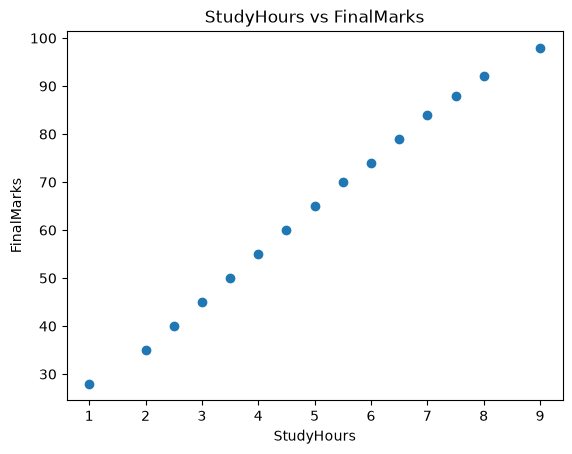

In [22]:
# Select Feature (X) and Target (y)

X = df[["StudyHours"]]
y = df["FinalMarks"]

plt.scatter(X, y)
plt.xlabel("StudyHours")
plt.ylabel("FinalMarks")
plt.title("StudyHours vs FinalMarks")

# for faster calculations, convert to numpy array
X = X.to_numpy()
y = y.to_numpy()

In [50]:
# Train-Test Split (80% Train, 20% Test)

X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size = 0.2,
    random_state = 42
)

X_test

array([[6.],
       [7.],
       [1.]])

In [26]:
# Train Linear Regression Model

model = LinearRegression() #Model Create

model.fit(X_train, y_train) #Give Train Data to the model


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[9.25]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,17.74
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[7.51]


In [53]:
#Test

predicted_y = model.predict(X_test)

comparision = pd.DataFrame({
    "Actual" : y_test,
    "Predicted" : predicted_y
    })

comparision

,Actual,Predicted
0,74,73.227474
1,84,82.475628
2,28,26.986706


In [54]:
new_students = np.array([
    [2],
    [4],
    [6],
    [8],
    [10]
])

marks_prediction = model.predict(new_students)
marks_prediction

array([ 36.23485968,  54.73116691,  73.22747415,  91.72378139,
       110.22008863])